# Previsão exploratória de preço de anúncios Airbnb

Este notebook avalia se os campos disponíveis conseguem explicar parte do preço informado no anúncio. O objetivo é diagnóstico: comparar um baseline simples com um modelo regularizado, medir o erro na escala de preço e identificar quais segmentos operacionais são mais difíceis de prever.

A previsão não representa preço recomendado. A fonte não contém reservas, ocupação, receita realizada ou calendário confiável.

## Como carregar a fonte sem depender de um caminho local do Kaggle?
O dataset é baixado pelo `kagglehub`, mantendo a origem reproduzível e fora do repositório.

In [1]:
%pip install -q kagglehub scikit-learn matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", None)
pd.options.display.float_format = "{:,.2f}".format

In [3]:
COR_PRIMARIA = "#0072B2"
COR_SECUNDARIA = "#94A3B8"
COR_DESTAQUE = "#E69F00"
COR_EIXO = "#B0B7C3"
COR_TEXTO = "#334155"
plt.rcParams.update({"figure.figsize": (10, 6), "figure.dpi": 110, "font.size": 11,
    "text.color": COR_TEXTO, "axes.titlesize": 15, "axes.titleweight": "bold",
    "axes.edgecolor": COR_EIXO, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "xtick.color": COR_EIXO, "ytick.color": COR_EIXO})

def reais(v):
    return f"R$ {v:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

In [4]:
import kagglehub

dataset_dir = Path(kagglehub.dataset_download("arianazmoudeh/airbnbopendata"))
csv_path = next(dataset_dir.glob("*.csv"))
df = pd.read_csv(csv_path, low_memory=False)
print(f"Arquivo: {csv_path.name} | Linhas: {df.shape[0]:,} | Colunas: {df.shape[1]}")

Arquivo: Airbnb_Open_Data.csv | Linhas: 102,599 | Colunas: 26


## A fonte foi carregada corretamente?
Confiro tamanho, rótulos e os campos que participarão da previsão antes das transformações.

In [5]:
preview_cols = ["id", "room type", "neighbourhood group", "price", "service fee", "availability 365"]
display(df[preview_cols].head().style.hide(axis="index"))
display(df.dtypes.astype("string").to_frame("tipo").loc[preview_cols])

id,room type,neighbourhood group,price,service fee,availability 365
1001254,Private room,Brooklyn,$966,$193,286.000000
1002102,Entire home/apt,Manhattan,$142,$28,228.000000
1002403,Private room,Manhattan,$620,$124,352.000000
1002755,Entire home/apt,Brooklyn,$368,$74,322.000000
1003689,Entire home/apt,Manhattan,$204,$41,289.000000


,tipo
id,int64
room type,str
neighbourhood group,str
price,str
service fee,str
availability 365,float64


A fonte é lida com os rótulos esperados. O preço chega como texto com símbolo monetário, portanto a transformação precisa ser explícita e auditável.

## Quais registros e campos são confiáveis para modelagem?
Vou remover IDs duplicados, converter números e transformar valores operacionais impossíveis em ausentes para que o pipeline faça a imputação.

In [6]:
df = df.drop_duplicates(subset="id", keep="first").copy()
for col in ["price", "service fee"]:
    df[f"{col}_num"] = pd.to_numeric(df[col].astype("string").str.replace(r"[$,]", "", regex=True), errors="coerce")
df["last_review_dt"] = pd.to_datetime(df["last review"], errors="coerce")
df.loc[~df["availability 365"].between(0, 365), "availability 365"] = np.nan
df.loc[~df["minimum nights"].between(1, 365), "minimum nights"] = np.nan
df.loc[~df["review rate number"].between(1, 5), "review rate number"] = np.nan
df = df[df["price_num"].gt(0)].copy()
display(df[["id", "price_num", "service fee_num", "availability 365", "minimum nights", "review rate number"]].head().style.hide(axis="index"))

id,price_num,service fee_num,availability 365,minimum nights,review rate number
1001254,966,193,286.000000,10.000000,4.000000
1002102,142,28,228.000000,30.000000,4.000000
1002403,620,124,352.000000,3.000000,5.000000
1002755,368,74,322.000000,30.000000,4.000000
1003689,204,41,289.000000,10.000000,3.000000


A preparação elimina duplicidade de anúncio, preserva a origem e evita que valores impossíveis sejam tratados como sinal real. `service fee` não entrará como explicador: ele é potencialmente derivado do próprio preço e poderia vazar a resposta para o modelo.

## Como é a distribuição do preço-alvo?
A escala logarítmica será usada no modelo para reduzir o peso de anúncios muito caros, mas a avaliação será traduzida de volta para reais.

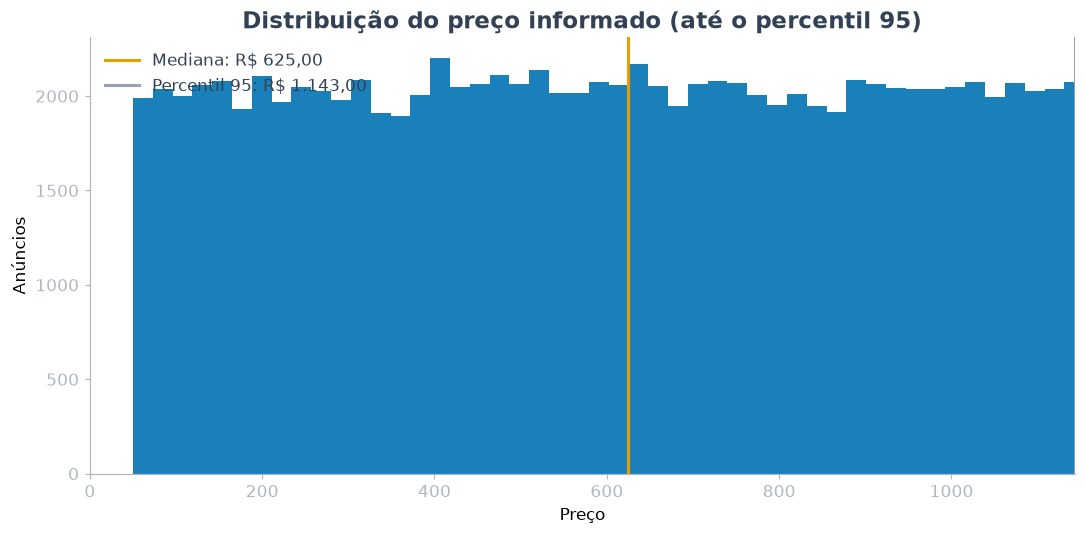

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["price_num"], bins=50, color=COR_PRIMARIA, alpha=.9)
mediana = df["price_num"].median()
p95 = df["price_num"].quantile(.95)
ax.axvline(mediana, color=COR_DESTAQUE, linewidth=2, label=f"Mediana: {reais(mediana)}")
ax.axvline(p95, color=COR_SECUNDARIA, linewidth=2, label=f"Percentil 95: {reais(p95)}")
ax.set_xlim(0, p95)
ax.set_title("Distribuição do preço informado (até o percentil 95)")
ax.set_xlabel("Preço")
ax.set_ylabel("Anúncios")
ax.legend(frameon=False)
plt.tight_layout()

A distribuição deve ser interpretada como preço cadastrado, não preço praticado. A concentração artificial em uma faixa estreita reduz o que o modelo pode aprender sobre diferenciação de mercado.

## Quais variáveis entram na previsão?
Uso atributos do anúncio, localização, reputação e disponibilidade. IDs, nomes, taxa de serviço e data textual ficam fora para reduzir vazamento e ruído.

In [8]:
numeric_features = ["minimum nights", "number of reviews", "reviews per month", "review rate number", "calculated host listings count", "availability 365", "Construction year", "lat", "long"]
cat_features = ["room type", "neighbourhood group", "neighbourhood", "host_identity_verified", "cancellation_policy", "instant_bookable"]
model_cols = numeric_features + cat_features
model_df = df[model_cols + ["price_num"]].copy()
X = model_df[model_cols]
y = np.log1p(model_df["price_num"])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.20, random_state=42)
print(f"Treino: {len(X_train):,} | Teste: {len(X_test):,} | Variáveis: {len(model_cols)}")

Treino: 81,448 | Teste: 20,363 | Variáveis: 15


## O modelo supera uma referência simples?
O baseline prevê sempre a mediana do treino. O Ridge recebe imputação, padronização e codificação dentro do pipeline, evitando que o teste influencie a preparação.

In [9]:
numeric_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
cat_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))])
preprocessor = ColumnTransformer([("num", numeric_pipe, numeric_features), ("cat", cat_pipe, cat_features)])
models = {"Baseline mediana": DummyRegressor(strategy="median"), "Ridge": Pipeline([("prep", preprocessor), ("model", Ridge(alpha=10.0))])}

In [10]:
results = []
predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred_log = model.predict(X_test)
    actual = np.expm1(y_test)
    predicted = np.maximum(0, np.expm1(pred_log))
    predictions[name] = predicted
    results.append({"modelo": name, "MAE": mean_absolute_error(actual, predicted), "RMSE": mean_squared_error(actual, predicted) ** .5, "R2": r2_score(actual, predicted)})
metrics = pd.DataFrame(results).sort_values("MAE")
display(metrics.style.format({"MAE": reais, "RMSE": reais, "R2": "{:.3f}"}).hide(axis="index"))

modelo,MAE,RMSE,R2
Baseline mediana,"R$ 287,14","R$ 331,63",-0.000
Ridge,"R$ 298,51","R$ 351,48",-0.123


A comparação só é útil se o Ridge melhorar o baseline na mesma base de teste. Mesmo quando melhora, o erro deve ser lido em reais e combinado com os alertas de qualidade; desempenho preditivo não transforma o preço cadastrado em preço recomendado.

## Quanto cada modelo erra?
O gráfico traduz o erro médio absoluto para uma comparação operacional direta.

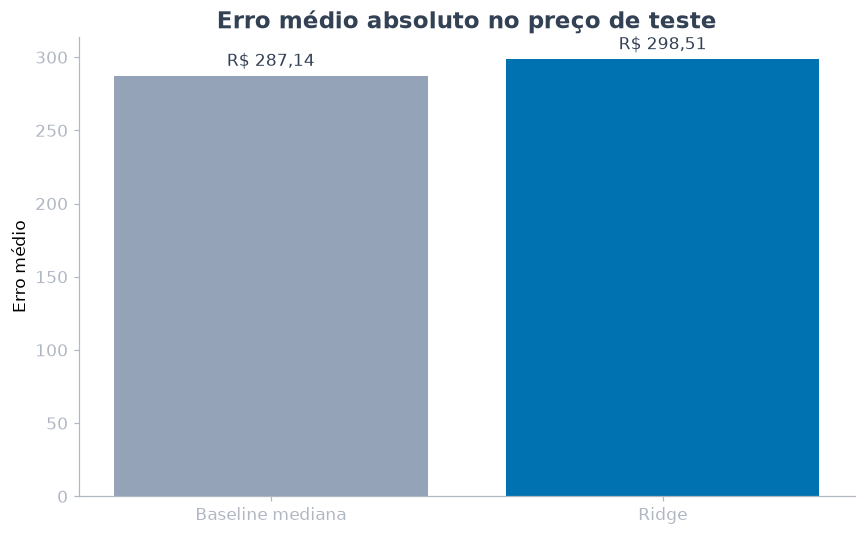

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(metrics["modelo"], metrics["MAE"], color=[COR_SECUNDARIA if m.startswith("Baseline") else COR_PRIMARIA for m in metrics["modelo"]])
ax.bar_label(bars, labels=[reais(v) for v in metrics["MAE"]], padding=4)
ax.set_title("Erro médio absoluto no preço de teste")
ax.set_ylabel("Erro médio")
plt.tight_layout()

O MAE é a medida mais fácil de levar para a operação: em média, o preço previsto se afasta do preço cadastrado por esse valor. Ele não mede ocupação, margem ou conversão.

## Em quais tipos de imóvel o modelo é menos confiável?
Comparo o erro por tipo de imóvel e mantenho o tamanho de cada grupo visível.

In [12]:
ridge_pred = predictions["Ridge"]
eval_df = X_test.copy()
eval_df["actual_price"] = np.expm1(y_test)
eval_df["predicted_price"] = ridge_pred
eval_df["abs_error"] = (eval_df["actual_price"] - eval_df["predicted_price"]).abs()
by_room = (eval_df.assign(room_type=eval_df["room type"].fillna("Não informado"))
    .groupby("room_type").agg(anuncios=("abs_error", "size"), MAE=("abs_error", "mean"), preco_medio=("actual_price", "mean"))
    .sort_values("MAE", ascending=False).reset_index())
display(by_room.style.format({"MAE": reais, "preco_medio": reais}).hide(axis="index"))

room_type,anuncios,MAE,preco_medio
Hotel room,15,"R$ 363,50","R$ 802,47"
Shared room,453,"R$ 320,74","R$ 656,55"
Private room,9272,"R$ 298,01","R$ 628,67"
Entire home/apt,10623,"R$ 297,91","R$ 619,83"


Esse recorte mostra onde o erro absoluto é maior, mas não deve ser comparado sem considerar o preço médio e o tamanho do grupo. Um segmento pequeno pode parecer instável por poucos casos.

## Quais variáveis mais influenciam o Ridge?
Os coeficientes são sinais de associação dentro deste modelo, não efeitos causais.

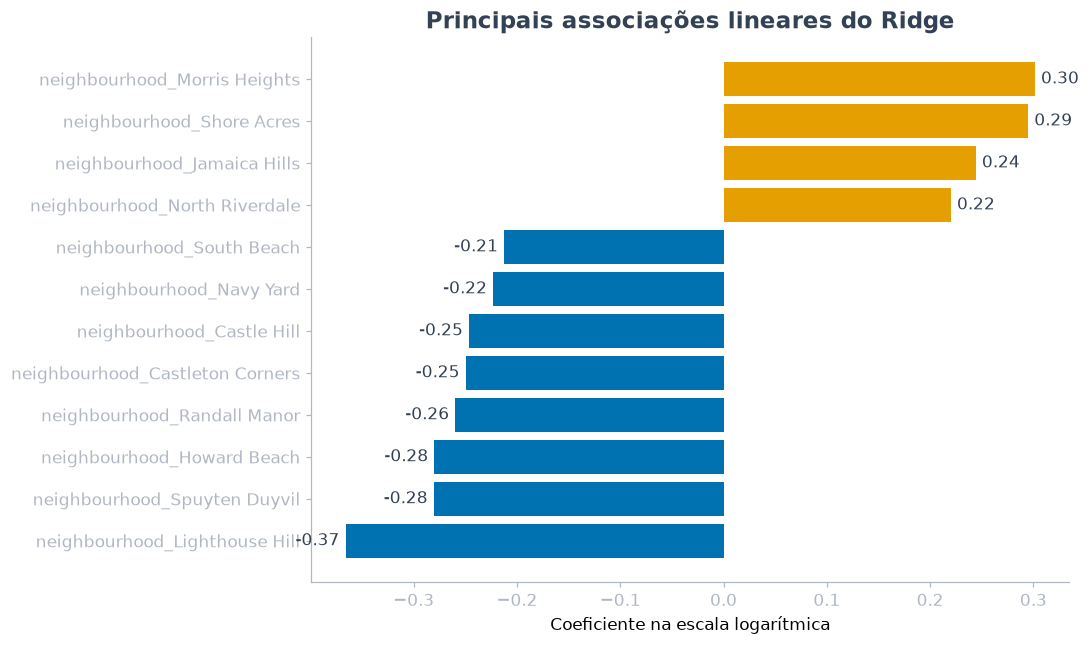

In [13]:
ridge = models["Ridge"]
feature_names = ridge.named_steps["prep"].get_feature_names_out()
coefs = ridge.named_steps["model"].coef_
importance = pd.DataFrame({"variavel": feature_names, "coeficiente": coefs, "abs_coeficiente": np.abs(coefs)})
top_features = importance.sort_values("abs_coeficiente", ascending=False).head(12).sort_values("coeficiente")
fig, ax = plt.subplots(figsize=(10, 6))
colors = [COR_DESTAQUE if v > 0 else COR_PRIMARIA for v in top_features["coeficiente"]]
bars = ax.barh(top_features["variavel"].str.replace("num__", "").str.replace("cat__", ""), top_features["coeficiente"], color=colors)
ax.bar_label(bars, labels=[f"{v:.2f}" for v in top_features["coeficiente"]], padding=4)
ax.set_title("Principais associações lineares do Ridge")
ax.set_xlabel("Coeficiente na escala logarítmica")
plt.tight_layout()

Os coeficientes ajudam a gerar hipóteses para investigação, mas não provam que uma característica causa aumento ou redução do preço. Relações geográficas e de cadastro podem estar misturadas com disponibilidade e qualidade da fonte.

## O que falta antes de usar a previsão em uma decisão?

- Validar os preços contra uma fonte de reservas ou transações reais.
- Definir uma referência temporal: treino e teste aleatórios não simulam necessariamente previsão futura.
- Testar divisão por anfitrião ou região para medir generalização fora da amostra.
- Comparar modelos não lineares e calibrar intervalos de incerteza.
- Criar uma regra de monitoramento para drift, dados ausentes e erro por segmento.

**Conclusão:** o notebook agora é executável e serve como baseline técnico. Ele ainda não deve ser usado para recomendar preços ou metas operacionais sem uma fonte de preço praticado e uma validação temporal.